### Part-1

In [24]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

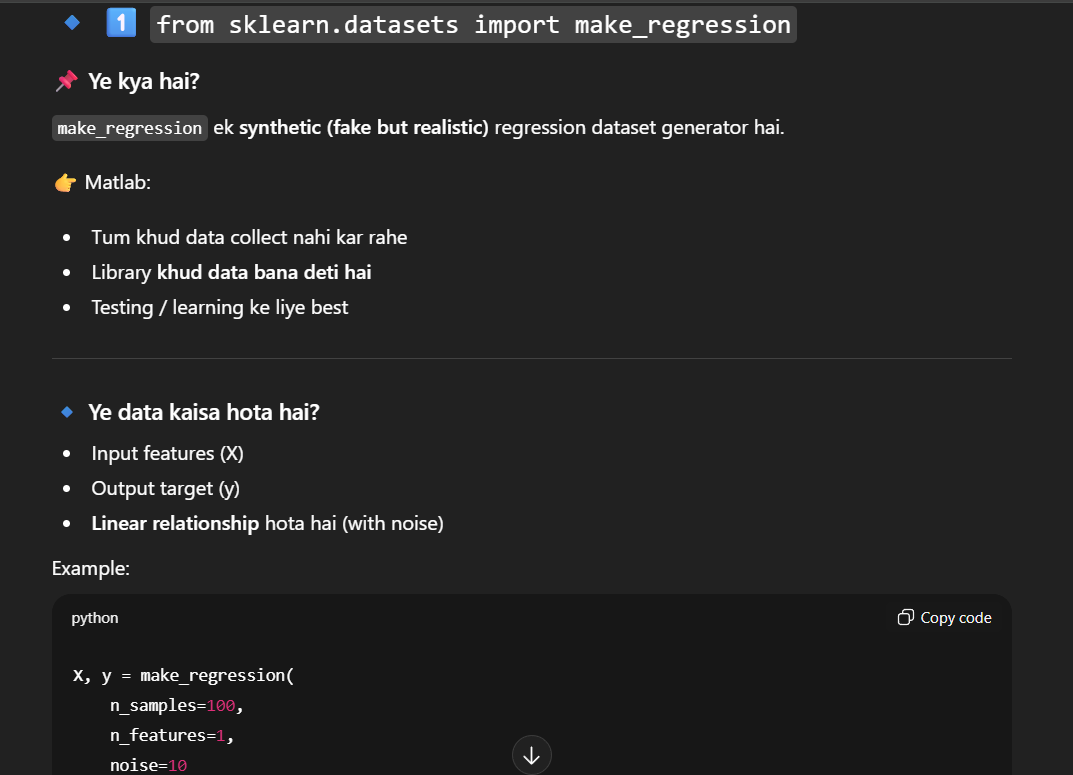

In [25]:
X, y = make_regression(
    n_samples=100, # ye 100 data point nikal ke deta hai 
    n_features=2,  # ye 2 input column generate karega 
    n_informative=2, # 👉 Kitne features actually y ko affect karte hain
    n_targets=1, # ye sure karta hai ki ek hi op aayega 
    noise=5  # ye data me thoda noise generate karta hai taaki lage ki real data ki tarah dikhe complexity ke hisab se 
)

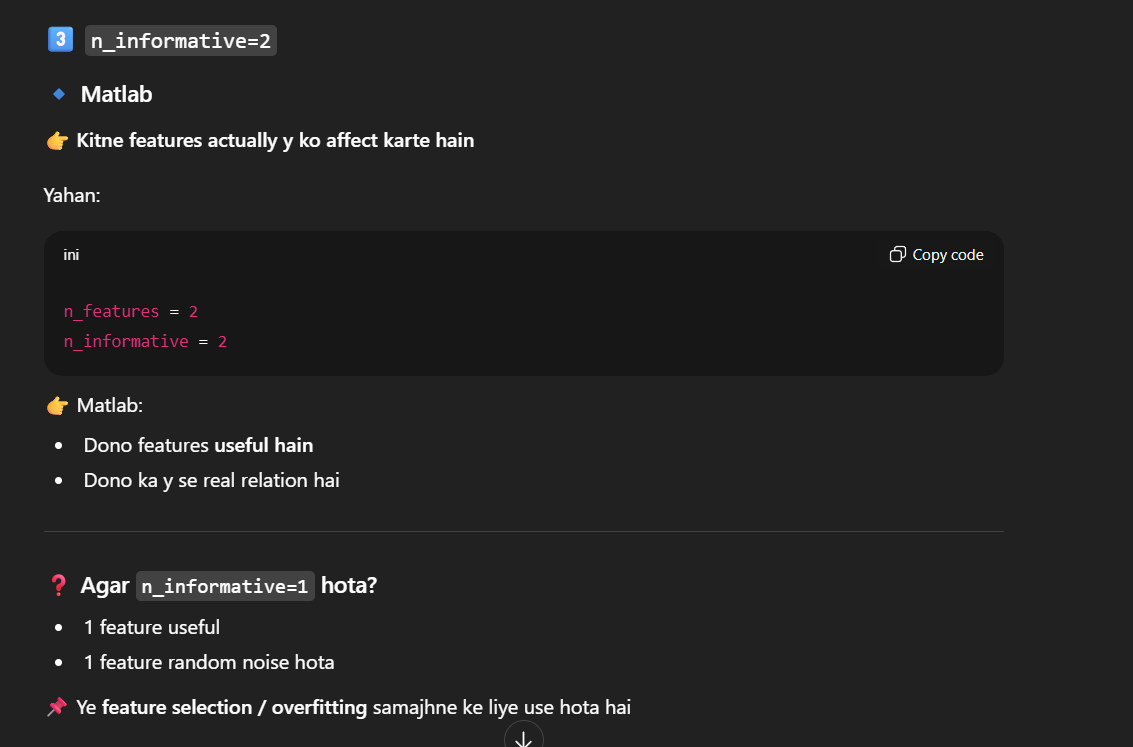

In [26]:
X.shape

(100, 2)

In [27]:
y.shape

(100,)

In [28]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [29]:
df.head()

,feature1,feature2,target
0,1.617457,-2.128193,-194.081313
1,0.285098,-1.039387,-97.069763
2,-0.050105,0.785996,57.398326
3,1.485879,0.719215,69.869757
4,1.424193,2.514930,234.032868


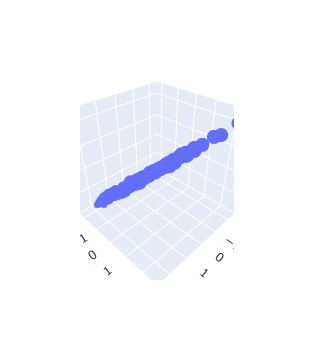

In [30]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()

# is code ko neeche ki tarah bhi likh sakte hain 

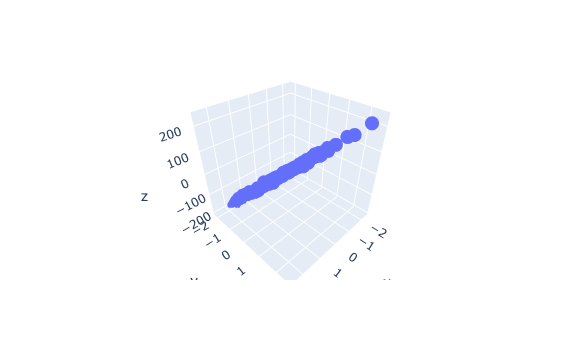

In [31]:
fig = px.scatter_3d(
    x=X[:,0],
    y=X[:,1],
    z=y
)
fig.show()

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
lr = LinearRegression()

In [35]:
lr.fit(X_train,y_train)

LinearRegression()

In [36]:
y_test

array([  51.30464251,   68.84574886,   37.65012555,  -35.83306926,
         91.10994847,    9.67363875,   -6.58123288,  -31.43553811,
       -109.09056358,  112.64916601,  -52.40479609, -195.90694728,
       -190.86850388,  -46.74702086, -153.40711942,  -77.94112276,
       -126.02482565,   50.08525865,   -3.84044657, -100.18701937])

In [37]:
y_pred = lr.predict(X_test)
# ab tum sochoge ki ab predict x_test hi q kar rahe hai 
# isliye kar rahehai qki x_test hi input column hai aur isi se predict karke ham y_test se compare karenge 
# ki hamra model kitna kaam kar raha hai 

In [38]:
y_pred

array([  55.83121444,   64.93293564,   33.4905054 ,  -31.08618178,
         90.77127265,    7.72820465,   -8.45771963,  -40.09106175,
       -114.14231153,  104.71894342,  -50.21779999, -192.10724475,
       -188.83947307,  -48.66018112, -151.83235043,  -81.01644452,
       -131.21599231,   49.59884416,   -8.63570446,  -97.87354715])

In [39]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

# dono me order change karne  se result same rahta hai but r2 score me thoda se change ho jata hai 

MAE 3.525463768576165
MSE 17.04247197113776
R2 score 0.9978255643712794


In [40]:
print("R2 score",r2_score(y_pred,y_test))

R2 score 0.9977668422118735


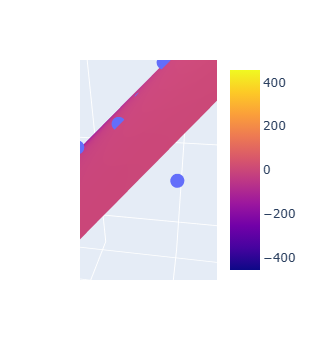

In [44]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

### Part-2

In [45]:
import numpy as np
from sklearn.datasets import load_diabetes

In [46]:
load_diabetes

<function sklearn.datasets._base.load_diabetes(*, return_X_y=False, as_frame=False, scaled=True)>

In [47]:
from sklearn.datasets import load_diabetes
X,y = load_diabetes(return_X_y=True)

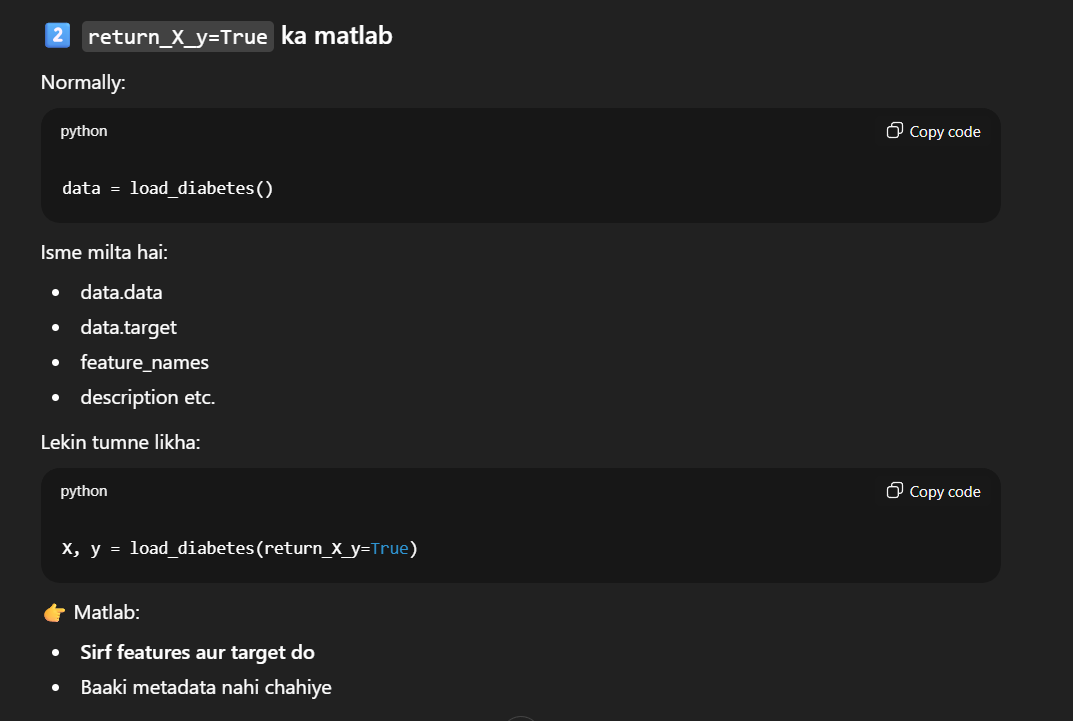

In [49]:
X.shape

(442, 10)

In [50]:
y.shape

(442,)

In [51]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

## Using Sklearn's Linear Regression

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [54]:
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [55]:
reg = LinearRegression()

In [56]:
reg.fit(X_train,y_train)

LinearRegression()

In [57]:
y_pred = reg.predict(X_test)

In [58]:
y_pred

array([154.1213881 , 204.81835118, 124.93755353, 106.08950893,
       258.5348576 , 256.3310074 , 118.75087616, 119.52440696,
       101.50816735, 190.54048661, 141.70656811, 172.51883961,
       174.33861649, 134.80942706, 294.13994537,  94.11798038,
       211.97059795, 156.49579378, 134.21000428, 119.62664644,
       148.87842251, 165.00873409, 151.10021038, 176.04063756,
       133.27769647, 221.29555392, 197.17324941,  96.1577688 ,
        50.26012711, 230.48580317, 242.06073866, 114.11129218,
        67.07532417,  94.52943825, 201.21415375, 167.05136201,
       159.881268  , 192.78746659, 114.49551325, 233.48234551,
       140.82563045, 121.0680409 , 192.27480772, 191.12738845,
       179.16865788, 148.34935601, 163.47414622, 276.81647884,
       100.17926432, 164.10555298, 255.80762189, 136.9466204 ,
       152.37503699, 107.92237882, 194.21924678,  77.34670792,
       118.50482479,  68.38335763, 154.29258529, 162.48840259,
       168.36788326, 156.87790322,  97.14191797, 238.16

In [59]:
y_test

array([ 73., 233.,  97., 111., 277., 341.,  64.,  68.,  65., 178., 142.,
        77., 244., 115., 258.,  87., 220.,  86.,  74., 132., 136., 220.,
        91., 235., 148., 317., 131.,  84.,  65., 217., 306.,  79., 158.,
        54., 123., 174., 237., 212., 179., 281., 187., 200.,  68., 163.,
       141., 202., 178., 242.,  47., 131., 243., 142., 200.,  89., 232.,
        55., 253., 128., 104., 184., 110., 198.,  81., 195., 150.,  63.,
       151., 233., 178.,  84., 237., 109., 131., 252., 200., 160., 200.,
        51., 111.,  77., 201.,  88.,  78., 243., 268.,  55., 270., 288.,
        91.])

In [60]:
from sklearn.metrics import r2_score

In [61]:
r2_score(y_test,y_pred)

0.4399338661568968

In [62]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [63]:
reg.intercept_

151.88331005254167

## Making our own Linear Regression Class

In [74]:
class MeraLR:
    
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)
        
        # calcuate the coeffs
        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]
    
    def predict(self,X_test):
        y_pred = np.dot(X_test,self.coef_) + self.intercept_
        return y_pred
        
    

In [75]:
lr = MeraLR()

In [76]:
lr.fit(X_train,y_train)

In [78]:
X_train.shape

(353, 10)

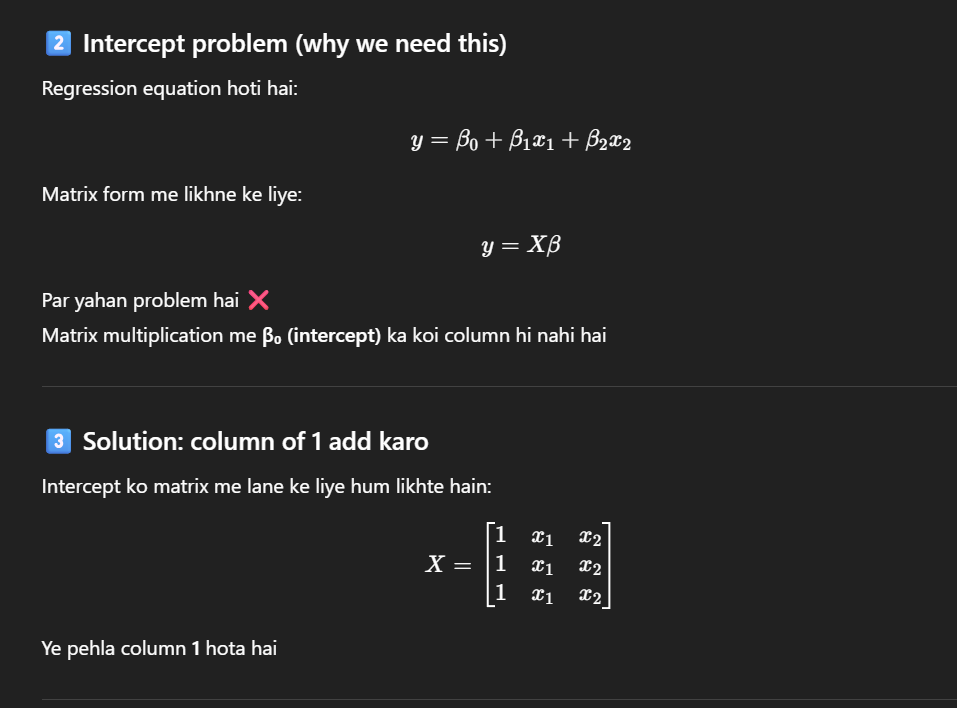

In [80]:
np.insert(X_train,0,1,axis=1).shape

# jab ham apne formula ko matrix form me likhte hai to 
# usme hame intercept wala column hi nahi rahta hai isiliye ek naya column add karna pad raha hai

(353, 11)

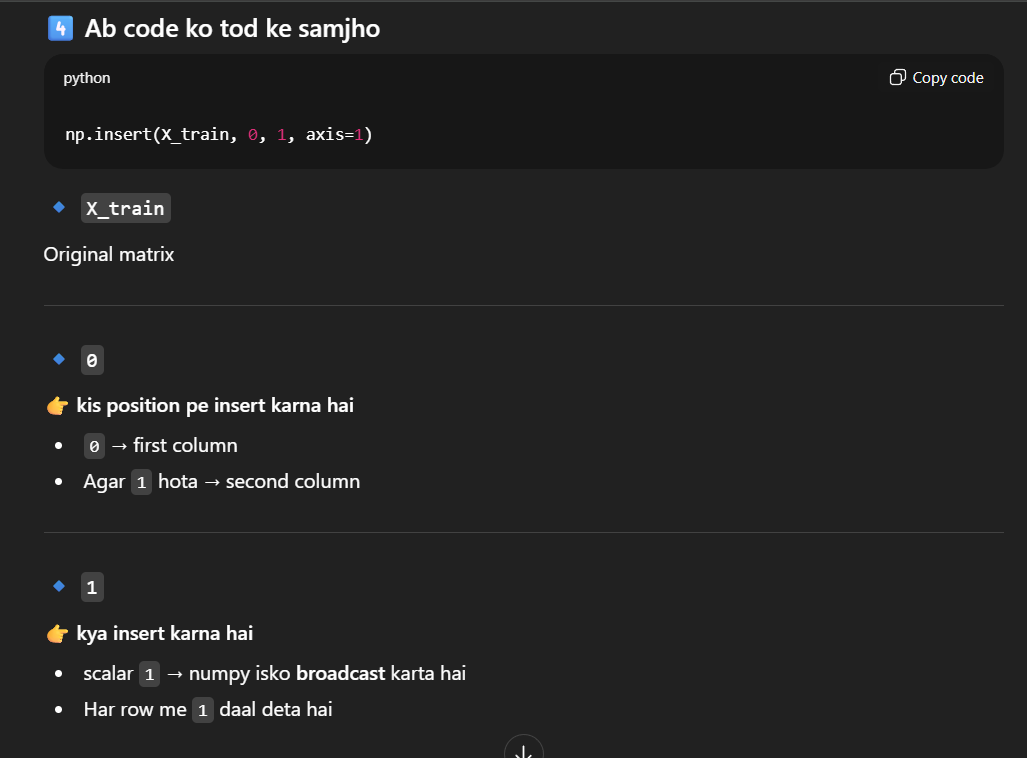

In [81]:
y_pred = lr.predict(X_test)

In [83]:
y_test

array([ 73., 233.,  97., 111., 277., 341.,  64.,  68.,  65., 178., 142.,
        77., 244., 115., 258.,  87., 220.,  86.,  74., 132., 136., 220.,
        91., 235., 148., 317., 131.,  84.,  65., 217., 306.,  79., 158.,
        54., 123., 174., 237., 212., 179., 281., 187., 200.,  68., 163.,
       141., 202., 178., 242.,  47., 131., 243., 142., 200.,  89., 232.,
        55., 253., 128., 104., 184., 110., 198.,  81., 195., 150.,  63.,
       151., 233., 178.,  84., 237., 109., 131., 252., 200., 160., 200.,
        51., 111.,  77., 201.,  88.,  78., 243., 268.,  55., 270., 288.,
        91.])

In [82]:
y_pred

array([154.1213881 , 204.81835118, 124.93755353, 106.08950893,
       258.5348576 , 256.3310074 , 118.75087616, 119.52440696,
       101.50816735, 190.54048661, 141.70656811, 172.51883961,
       174.33861649, 134.80942706, 294.13994537,  94.11798038,
       211.97059795, 156.49579378, 134.21000428, 119.62664644,
       148.87842251, 165.00873409, 151.10021038, 176.04063756,
       133.27769647, 221.29555392, 197.17324941,  96.1577688 ,
        50.26012711, 230.48580317, 242.06073866, 114.11129218,
        67.07532417,  94.52943825, 201.21415375, 167.05136201,
       159.881268  , 192.78746659, 114.49551325, 233.48234551,
       140.82563045, 121.0680409 , 192.27480772, 191.12738845,
       179.16865788, 148.34935601, 163.47414622, 276.81647884,
       100.17926432, 164.10555298, 255.80762189, 136.9466204 ,
       152.37503699, 107.92237882, 194.21924678,  77.34670792,
       118.50482479,  68.38335763, 154.29258529, 162.48840259,
       168.36788326, 156.87790322,  97.14191797, 238.16

In [84]:
r2_score(y_test,y_pred)

0.43993386615689645

In [85]:
lr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [86]:
lr.intercept_

151.88331005254167